MODEL DE REGRESSION MULTILINEAIRE POUR LE PREDICTION DE L'ESPERANCE DE VIE EN AFRIQUE

IMPORTATION DES LIBRAIRIES

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score,
    mean_absolute_percentage_error
)
from sklearn.feature_selection import SelectKBest, f_regression
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


IMPORTER LE DATASET

In [2]:
df = pd.read_csv('C:/Users/LENOVO/Desktop/SQL/Linkedin/python/African Life Expetancy Linear regression Model/Data/Processed/Life-Expectancy-Data-Updated.csv',index_col=0
)
print(f"Dataset chargé: {df.shape[0]} observations, {df.shape[1]} colonnes\n")

Dataset chargé: 2864 observations, 20 colonnes



CHARGEMENT DES 05 PREMIERES LIGNES 

In [3]:
print(df.head())

                 Region  Year  Infant_deaths  Under_five_deaths  \
Country                                                           
Turkiye     Middle East  2015          11.10              13.00   
Spain    European Union  2015           2.70               3.30   
India              Asia  2007          51.50              67.90   
Guyana    South America  2006          32.80              40.50   
Israel      Middle East  2012           3.40               4.30   

         Adult_mortality  Alcohol_consumption  Hepatitis_B  Measles   BMI  \
Country                                                                     
Turkiye           105.82                 1.32           97       65 27.80   
Spain              57.90                10.35           97       94 26.00   
India             201.08                 1.57           60       35 21.20   
Guyana            222.20                 5.68           93       74 25.30   
Israel             57.95                 2.89           97       89 

INFORMATIONS SUR LE DATASET

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 2864 entries, Turkiye to Iceland
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Region                       2864 non-null   str    
 1   Year                         2864 non-null   int64  
 2   Infant_deaths                2864 non-null   float64
 3   Under_five_deaths            2864 non-null   float64
 4   Adult_mortality              2864 non-null   float64
 5   Alcohol_consumption          2864 non-null   float64
 6   Hepatitis_B                  2864 non-null   int64  
 7   Measles                      2864 non-null   int64  
 8   BMI                          2864 non-null   float64
 9   Polio                        2864 non-null   int64  
 10  Diphtheria                   2864 non-null   int64  
 11  Incidents_HIV                2864 non-null   float64
 12  GDP_per_capita               2864 non-null   int64  
 13  Population_mln           

STATISTIQUES DESCRIPTIVES

In [5]:
print(df.describe())

         Year  Infant_deaths  Under_five_deaths  Adult_mortality  \
count 2864.00        2864.00            2864.00          2864.00   
mean  2007.50          30.36              42.94           192.25   
std      4.61          27.54              44.57           114.91   
min   2000.00           1.80               2.30            49.38   
25%   2003.75           8.10               9.67           106.91   
50%   2007.50          19.60              23.10           163.84   
75%   2011.25          47.35              66.00           246.79   
max   2015.00         138.10             224.90           719.36   

       Alcohol_consumption  Hepatitis_B  Measles     BMI   Polio  Diphtheria  \
count              2864.00      2864.00  2864.00 2864.00 2864.00     2864.00   
mean                  4.82        84.29    77.34   25.03   86.50       86.27   
std                   3.98        16.00    18.66    2.19   15.08       15.53   
min                   0.00        12.00    10.00   19.80    8.00   

VALEURS MANQUANTES

In [6]:
df.isnull().sum()



Region                         0
Year                           0
Infant_deaths                  0
Under_five_deaths              0
Adult_mortality                0
Alcohol_consumption            0
Hepatitis_B                    0
Measles                        0
BMI                            0
Polio                          0
Diphtheria                     0
Incidents_HIV                  0
GDP_per_capita                 0
Population_mln                 0
Thinness_ten_nineteen_years    0
Thinness_five_nine_years       0
Schooling                      0
Economy_status_Developed       0
Economy_status_Developing      0
Life_expectancy                0
dtype: int64

In [7]:
data=df.drop(columns=['Region', 'Year'])

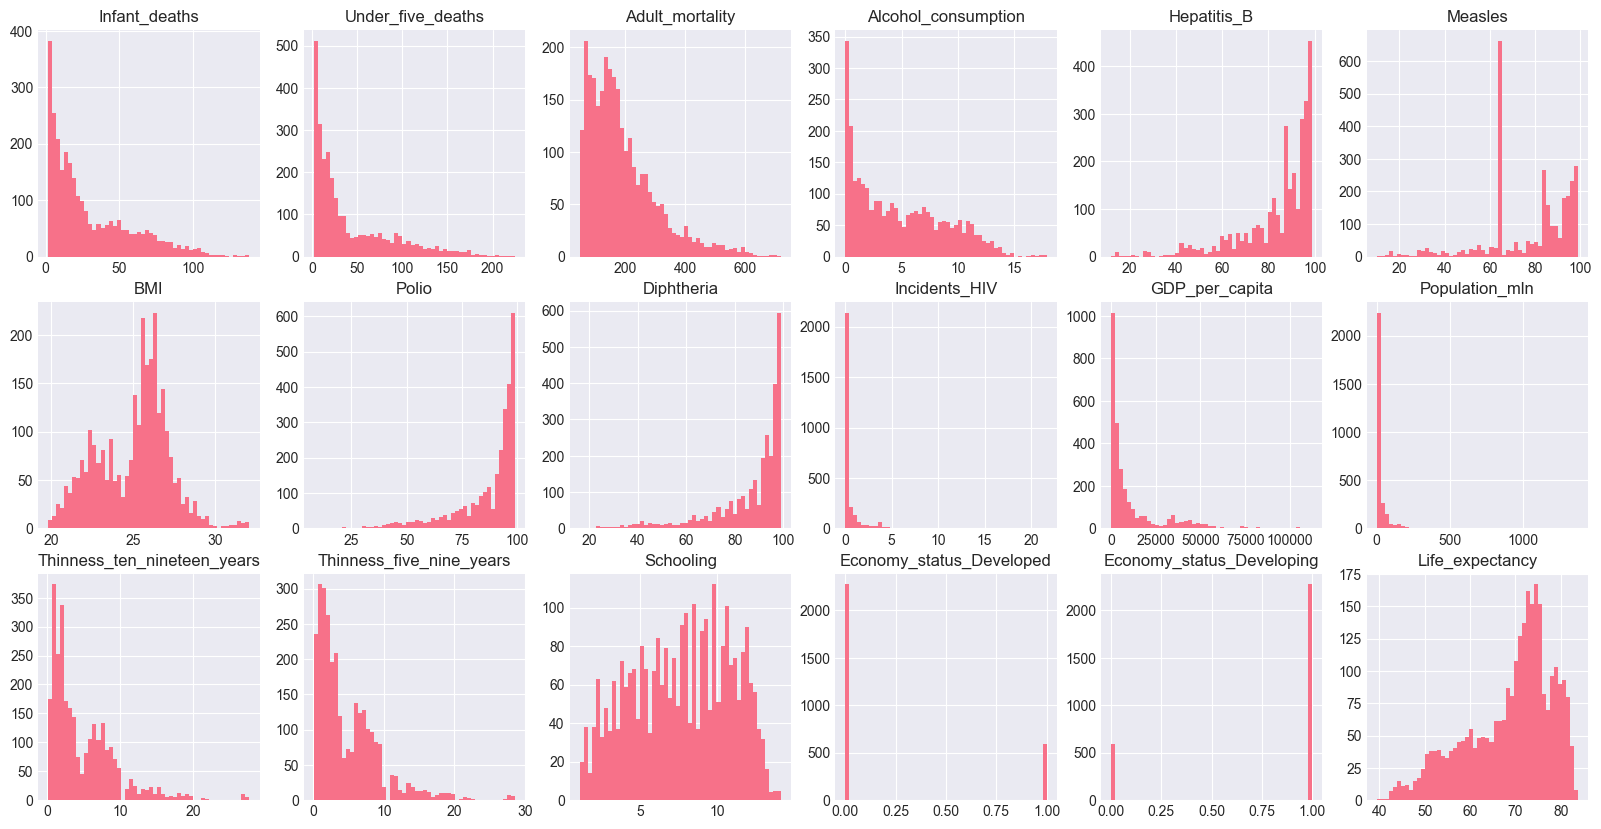

In [8]:
fig, axs = plt.subplots(3, 6, figsize=(20, 10))
axs = axs.ravel()

for i, column in enumerate(data.columns):
    axs[i].hist(df[column], bins=50)
    axs[i].set_title(column)

plt.show()


DISTRIBUTION DES VARIABLES

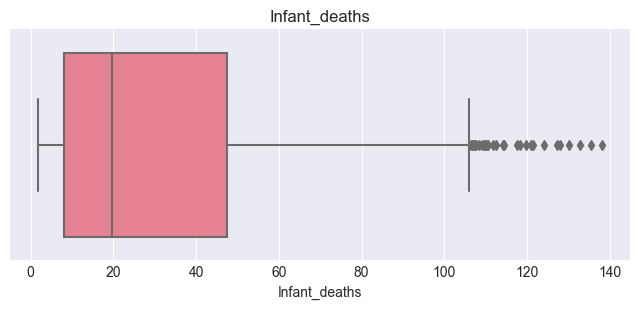

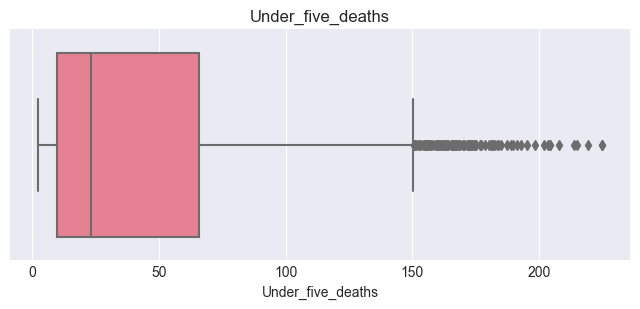

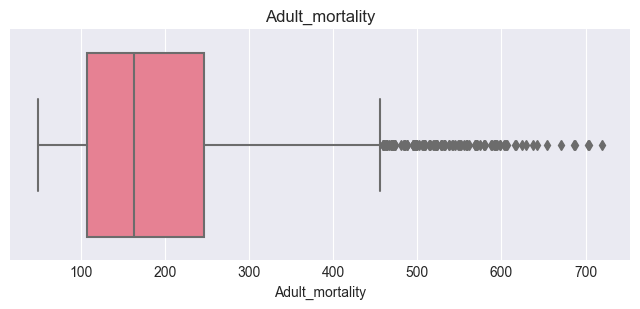

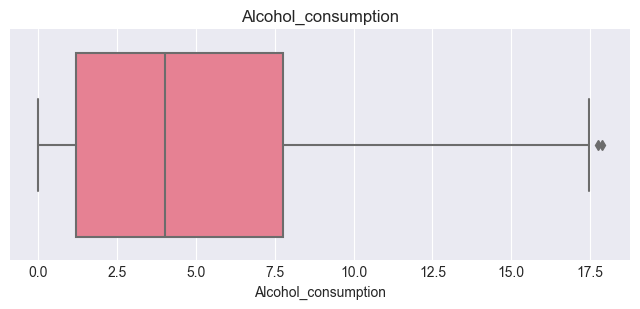

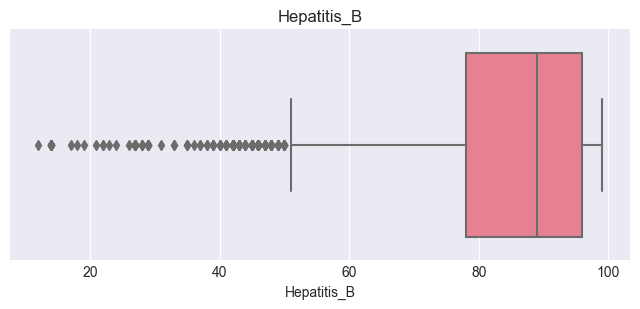

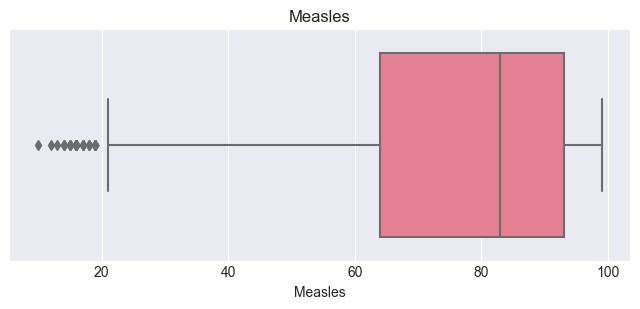

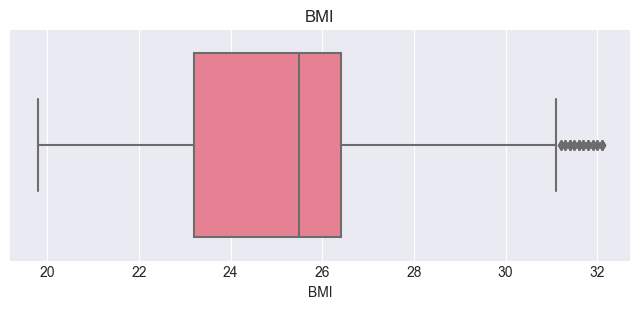

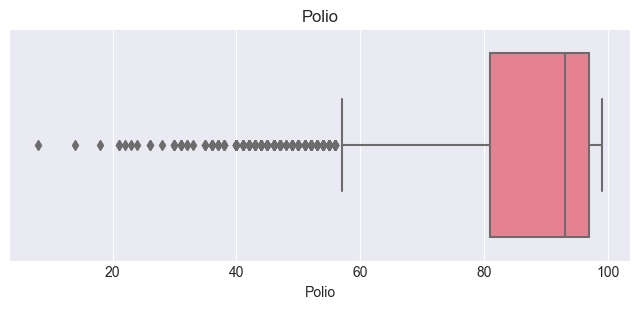

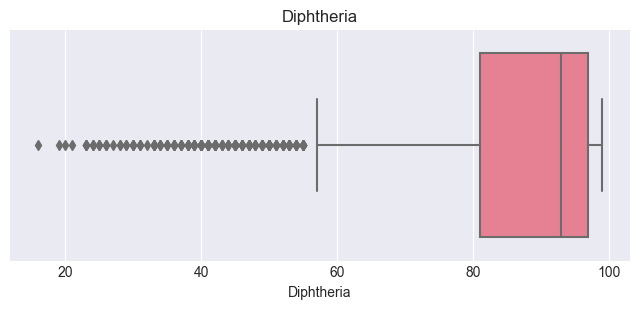

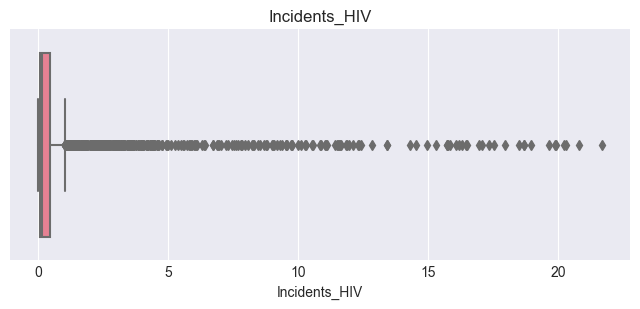

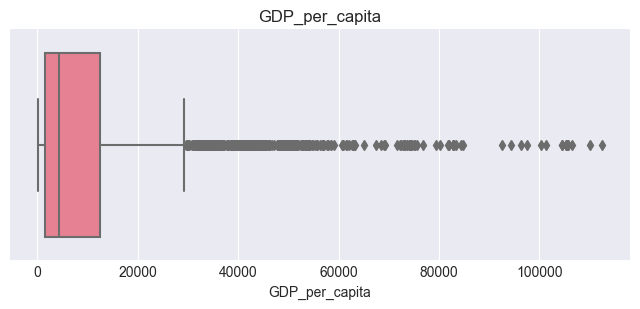

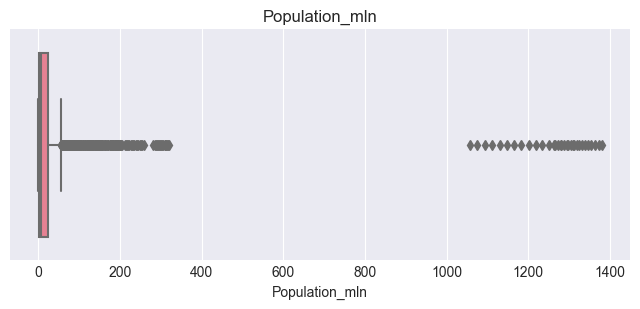

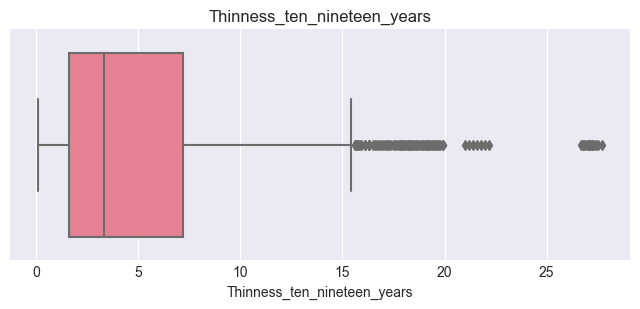

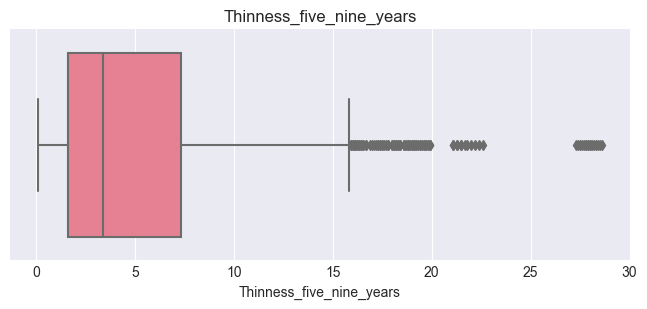

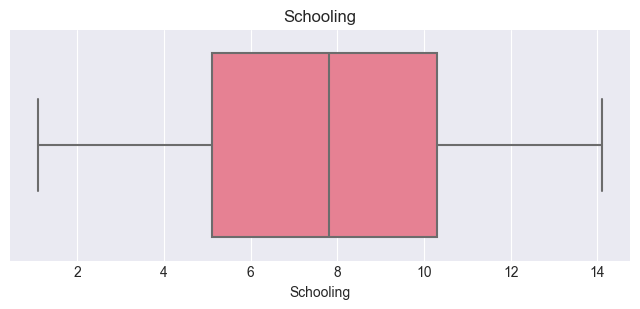

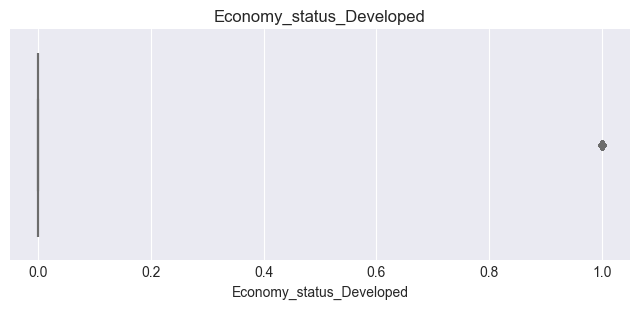

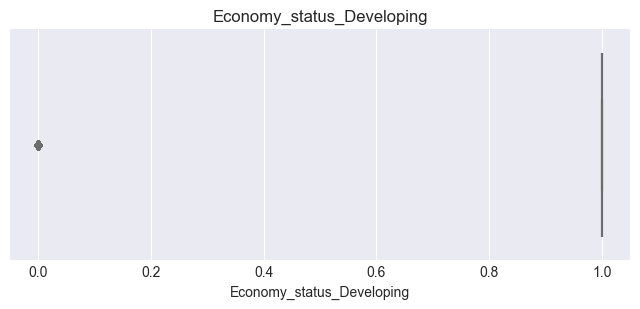

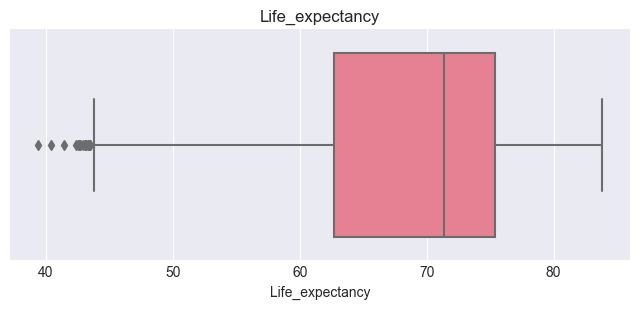

In [9]:
# Tracé des boxplots pour chaque variable
for column in data.columns:
    fig, ax = plt.subplots(figsize=(8, 3))
    sns.boxplot(x=data[column], ax=ax)
    plt.title(column)
    plt.show()

CORRELATION ENTRE LES VARIABLES

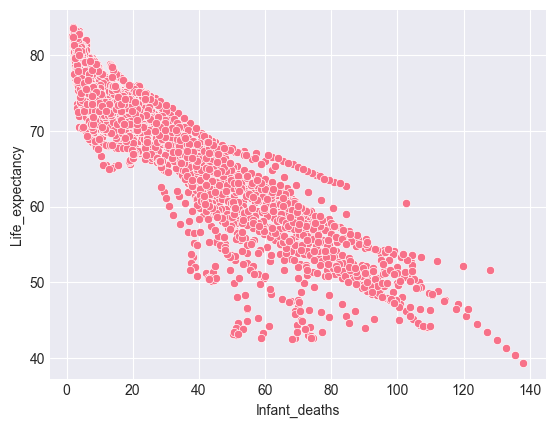

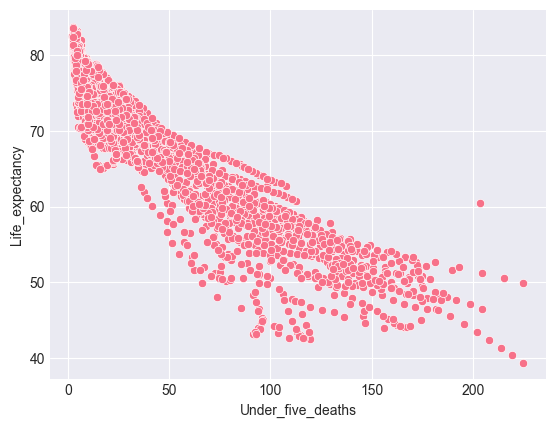

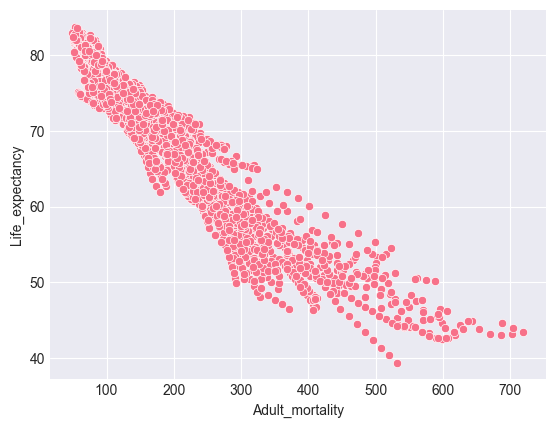

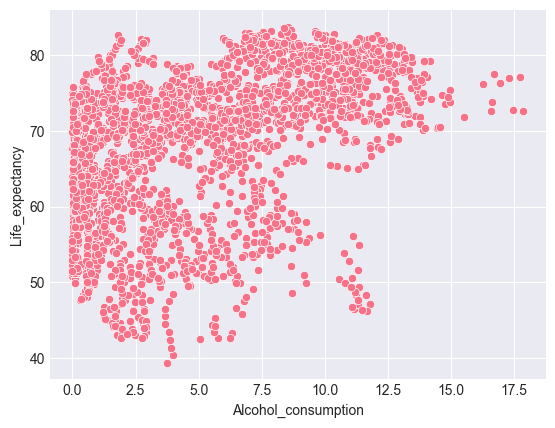

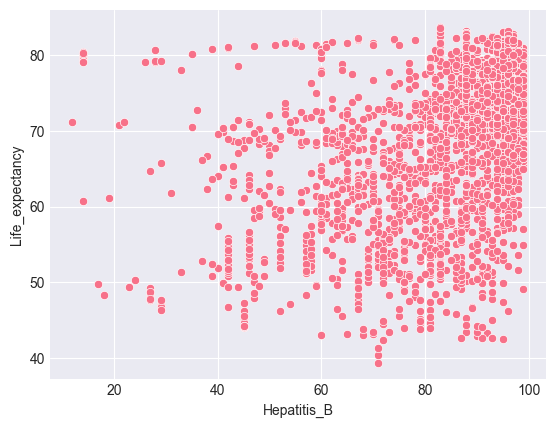

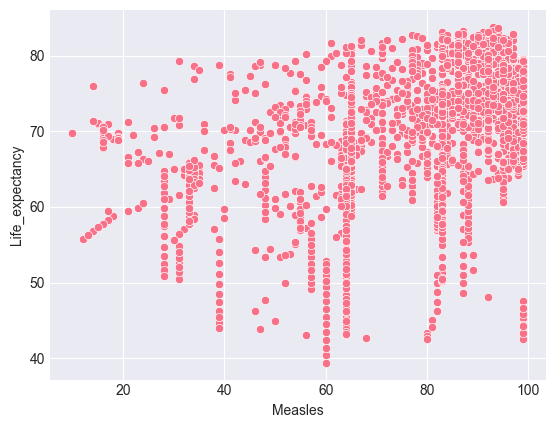

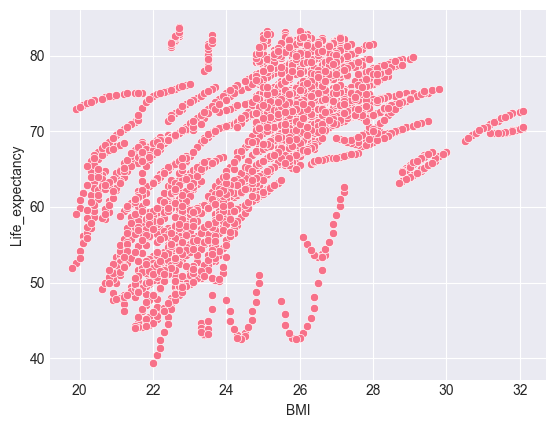

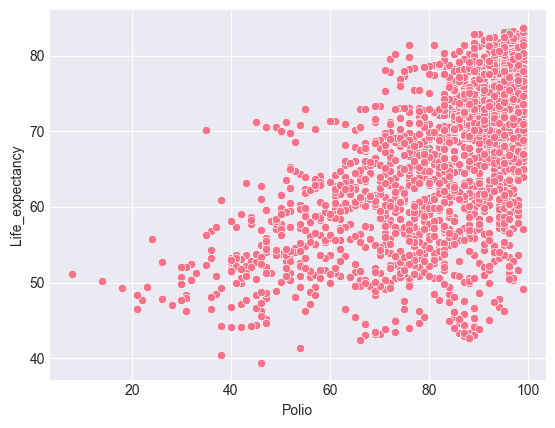

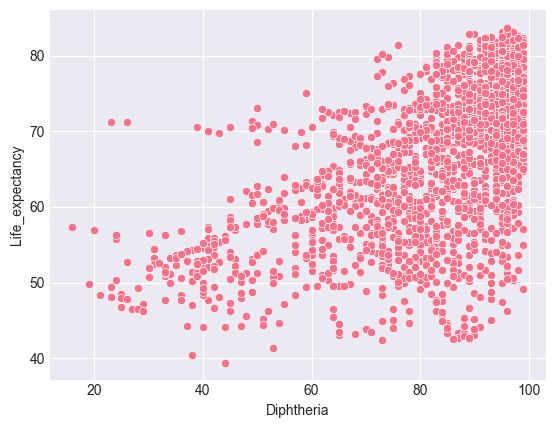

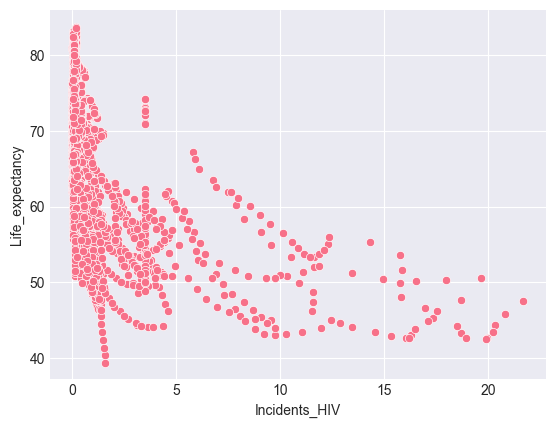

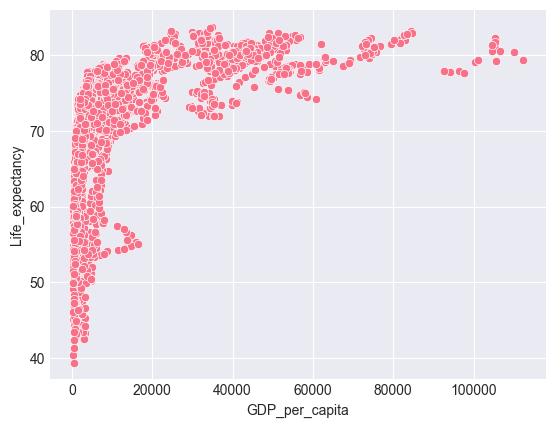

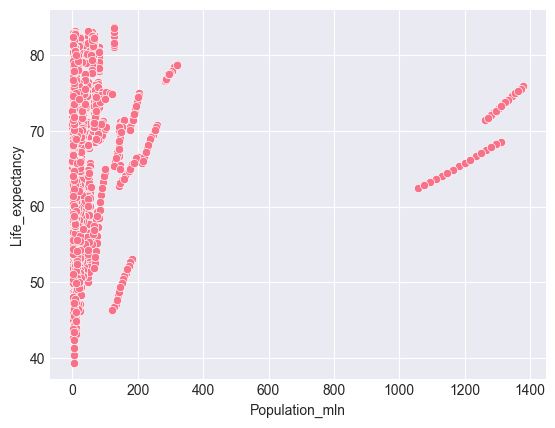

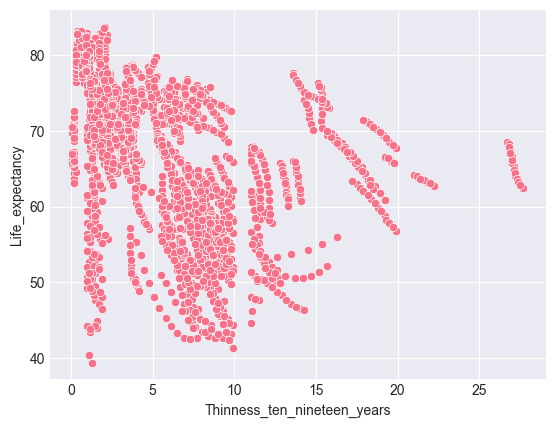

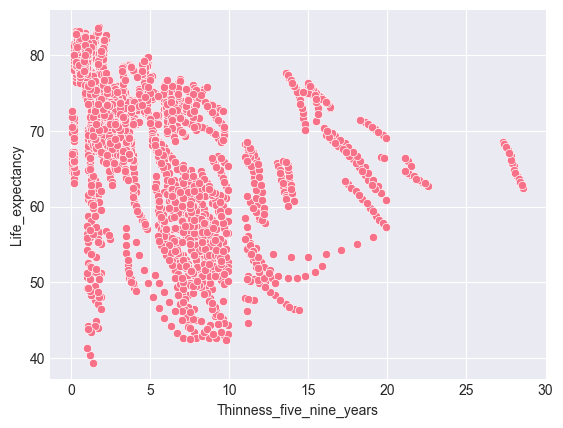

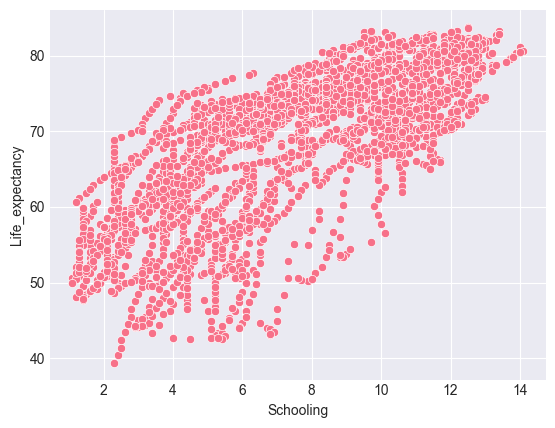

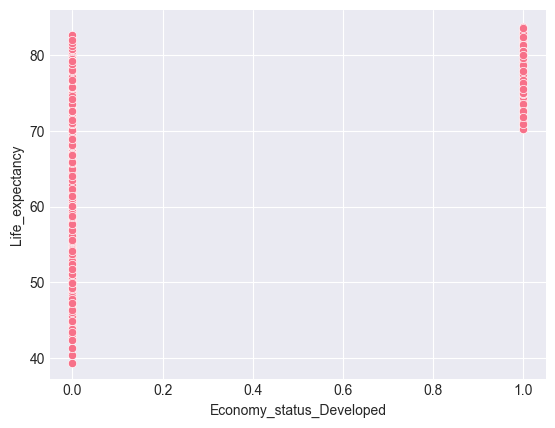

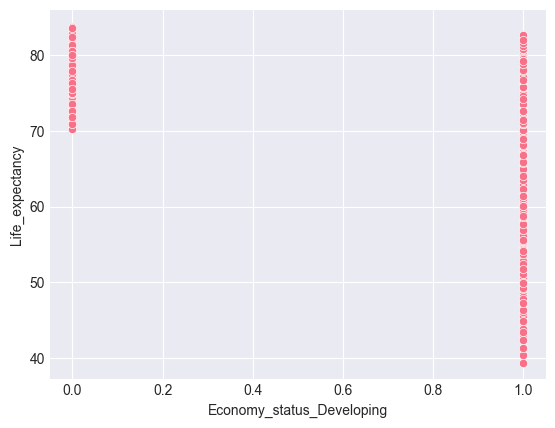

In [10]:
# Extraction des colonnes de variables explicatives
X = data.drop("Life_expectancy", axis=1)

# Affichage des nuages de points entre la variable à expliquer et toutes les variables explicatives avec seaborn
for col in X.columns:
    sns.scatterplot(x=X[col], y=data["Life_expectancy"])
    plt.show()

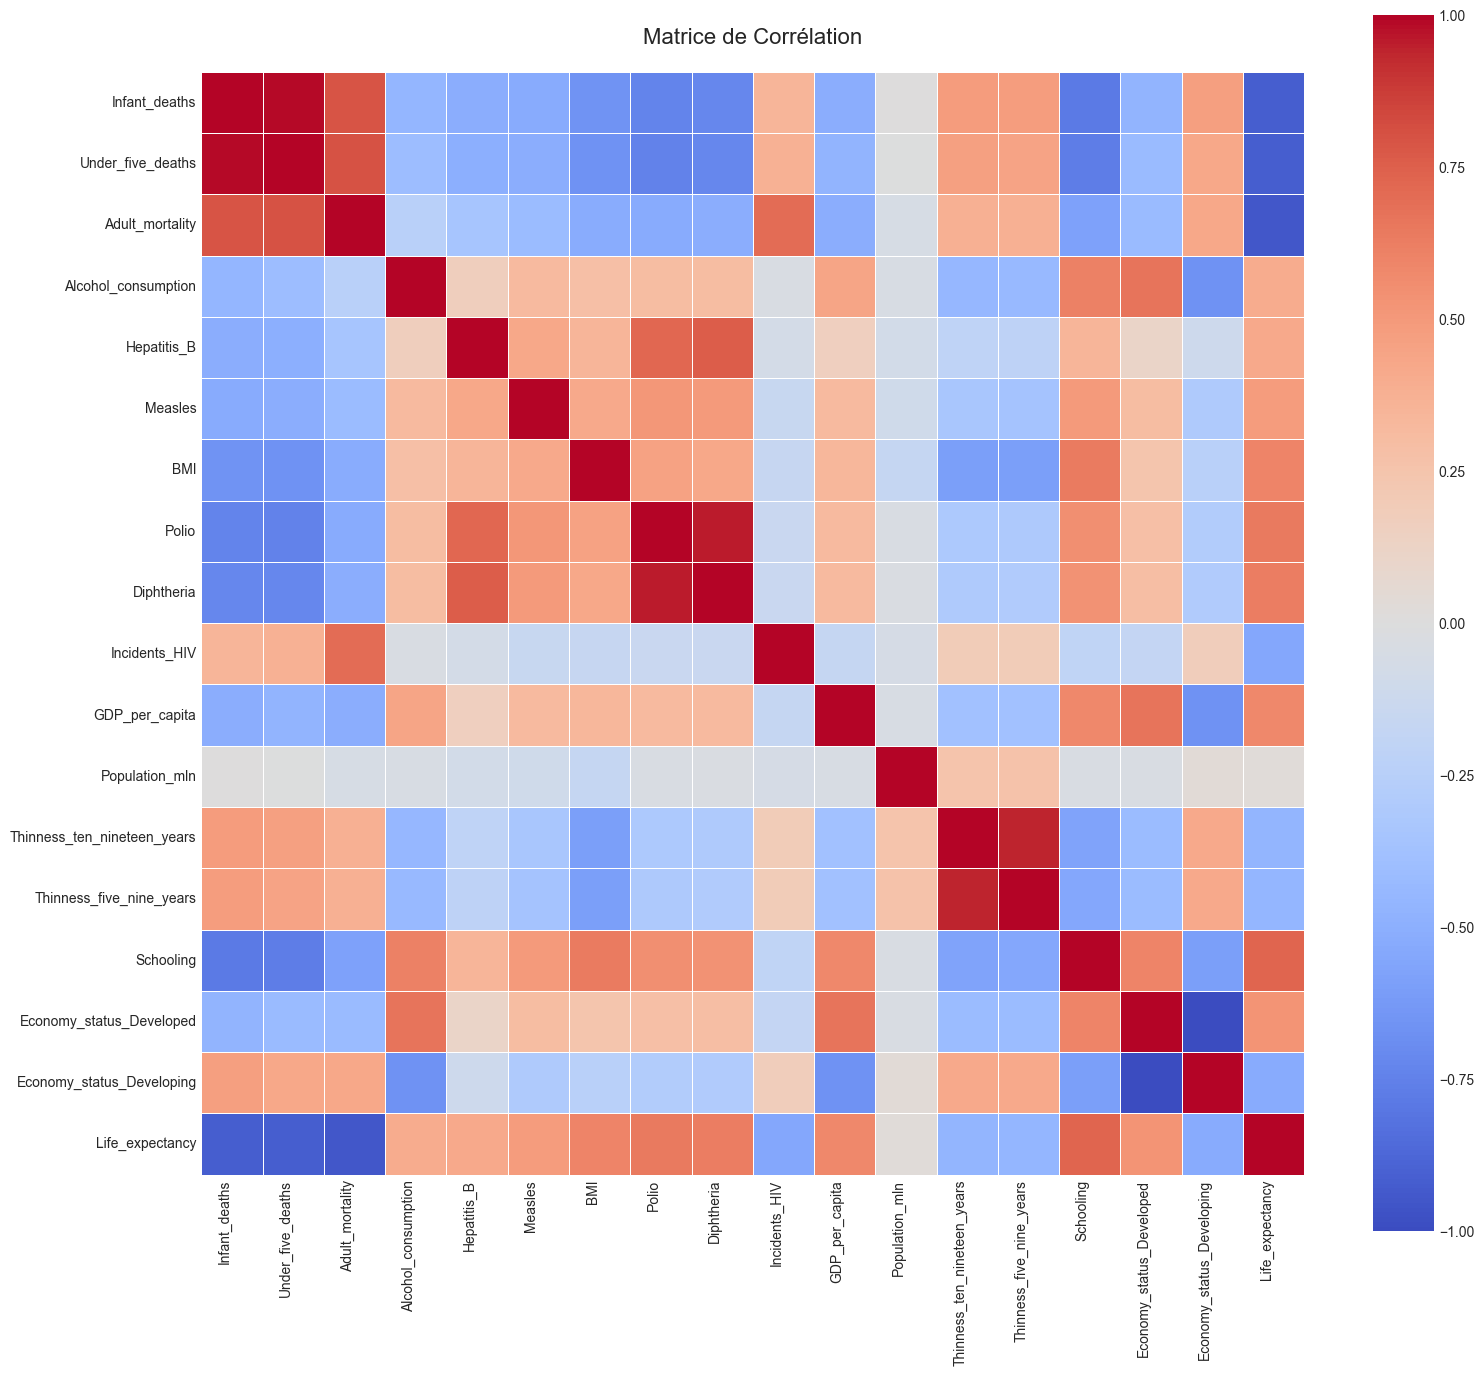

In [11]:
df_analysis = df.drop('Year', axis=1)
numeric_columns = df_analysis.select_dtypes(include=[np.number]).columns

correlation_matrix = df_analysis[numeric_columns].corr()

# Visualisation de la matrice de corrélation - VALEURS DANS TOUTES LES CASES
plt.figure(figsize=(16, 14))  # Figure plus grande pour toutes les cases
sns.heatmap(correlation_matrix, 
                 
            cmap='coolwarm', 
            center=0, 
            fmt='.2f', 
            square=True, 
            linewidths=0.5)  # Police légèrement réduite
plt.xticks(rotation=90, ha='right')  # Rotation à 90° pour éviter chevauchement
plt.yticks(rotation=0)
plt.title('Matrice de Corrélation', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

In [12]:
# Extraction des variables ayant une corrélation supérieure à 0.6 avec la variable d'intérêt
corr_matrix = data.corr()
corr_threshold = 0.6
corr_vars = corr_matrix[abs(corr_matrix["Life_expectancy"]) > corr_threshold].index.tolist()

# Affichage des variables ayant une corrélation supérieure à 0.6 avec la variable d'intérêt
print("Variables ayant une corrélation supérieure à 0.6 avec la variable d'intérêt (Life_expectancy) :\n")
print(corr_vars)

Variables ayant une corrélation supérieure à 0.6 avec la variable d'intérêt (Life_expectancy) :

['Infant_deaths', 'Under_five_deaths', 'Adult_mortality', 'Polio', 'Diphtheria', 'Schooling', 'Life_expectancy']


In [13]:
# Extraction des variables ayant une corrélation supérieure à 0.6 avec la variable d'intérêt
corr_threshold = 0.6
corr_vars = corr_matrix[abs(corr_matrix["Life_expectancy"]) <  corr_threshold].index.tolist()

# Affichage des variables ayant une corrélation supérieure à 0.6 avec la variable d'intérêt
print("Variables ayant une corrélation supérieure à 0.6 avec la variable d'intérêt (Life_expectancy) :\n")
print(corr_vars)

Variables ayant une corrélation supérieure à 0.6 avec la variable d'intérêt (Life_expectancy) :

['Alcohol_consumption', 'Hepatitis_B', 'Measles', 'BMI', 'Incidents_HIV', 'GDP_per_capita', 'Population_mln', 'Thinness_ten_nineteen_years', 'Thinness_five_nine_years', 'Economy_status_Developed', 'Economy_status_Developing']


In [14]:
# Extraction des couples de variables ayant une corrélation supérieure à 0.8
corr_threshold = 0.8
corr_pairs = {}

for col in corr_matrix.columns:
    corr_pairs[col] = []
    corr_values = corr_matrix[abs(corr_matrix[col]) > corr_threshold][col].index.tolist()
    for pair in corr_values:
        if pair != col:
            corr_pairs[col].append(pair)

# Affichage des couples de variables ayant une corrélation supérieure à 0.8
print("Couples de variables ayant une corrélation supérieure à 0.8 :\n")
for col, pairs in corr_pairs.items():
    if len(pairs) > 0:
        for pair in pairs:
            print(col, "-", pair)

Couples de variables ayant une corrélation supérieure à 0.8 :

Infant_deaths - Under_five_deaths
Infant_deaths - Life_expectancy
Under_five_deaths - Infant_deaths
Under_five_deaths - Adult_mortality
Under_five_deaths - Life_expectancy
Adult_mortality - Under_five_deaths
Adult_mortality - Life_expectancy
Polio - Diphtheria
Diphtheria - Polio
Thinness_ten_nineteen_years - Thinness_five_nine_years
Thinness_five_nine_years - Thinness_ten_nineteen_years
Economy_status_Developed - Economy_status_Developing
Economy_status_Developing - Economy_status_Developed
Life_expectancy - Infant_deaths
Life_expectancy - Under_five_deaths
Life_expectancy - Adult_mortality


Division en Train et en Test

In [15]:
# Diviser les données en ensembles d'apprentissage et de test

train, test = train_test_split(data, test_size=0.2, random_state=42)

Sélection des features sur la base train

In [16]:
# Résumé statistique des variables
train.describe()

,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
count,2291.00,2291.00,2291.00,2291.00,2291.00,2291.00,2291.00,2291.00,2291.00,2291.00,2291.00,2291.00,2291.00,2291.00,2291.00,2291.00,2291.00,2291.00
mean,30.51,43.21,193.07,4.83,84.19,77.33,25.03,86.55,86.29,0.91,11792.59,36.90,4.83,4.87,7.66,0.21,0.79,68.80
std,27.74,44.88,115.83,3.99,16.26,18.45,2.20,15.15,15.64,2.39,17244.32,137.29,4.39,4.48,3.19,0.41,0.41,9.48
min,1.80,2.30,49.38,0.00,12.00,10.00,19.80,8.00,16.00,0.01,148.00,0.08,0.10,0.10,1.10,0.00,0.00,40.40
25%,7.90,9.50,105.62,1.23,78.00,64.00,23.20,81.00,81.00,0.08,1382.50,2.26,1.50,1.50,5.05,0.00,1.00,62.50
50%,19.80,23.30,164.10,4.05,89.00,83.00,25.50,93.00,93.00,0.16,4219.00,8.11,3.30,3.30,7.90,0.00,1.00,71.30
75%,47.80,66.65,248.59,7.79,96.00,93.00,26.40,97.00,97.00,0.48,12900.50,24.69,7.30,7.30,10.35,0.00,1.00,75.50
max,135.60,224.90,703.68,17.87,99.00,99.00,32.10,99.00,99.00,21.68,112418.00,1379.86,27.70,28.60,14.00,1.00,1.00,83.60


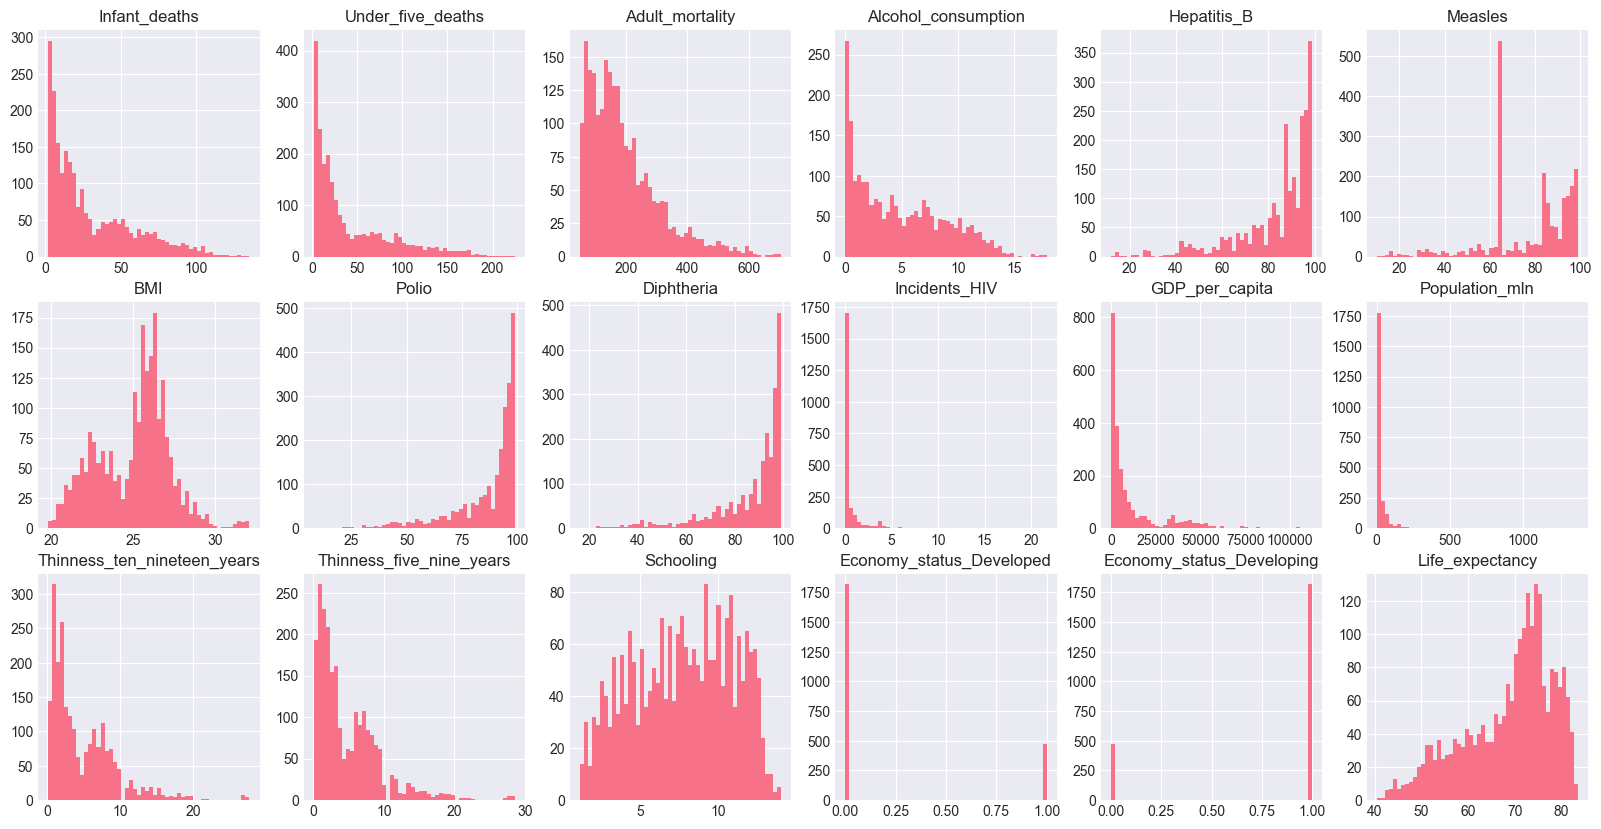

In [17]:
# Visualisation de la distribution des variables
fig, axs = plt.subplots(3, 6, figsize=(20, 10))
axs = axs.ravel()

for i, column in enumerate(train.columns):
    axs[i].hist(train[column], bins=50)
    axs[i].set_title(column)

plt.show()

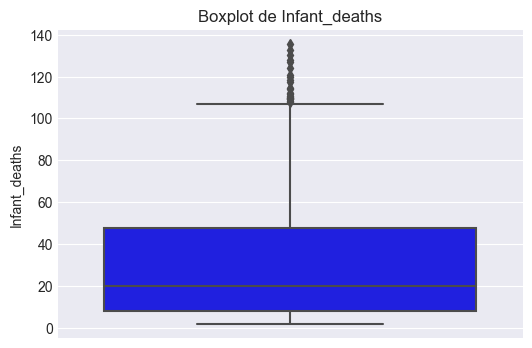

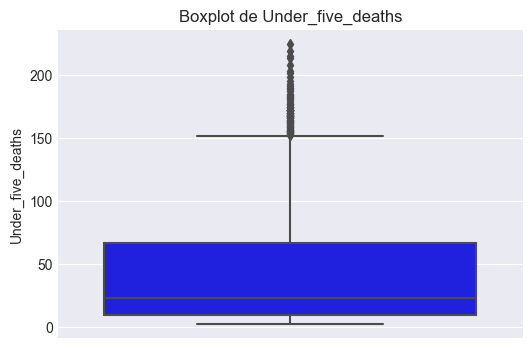

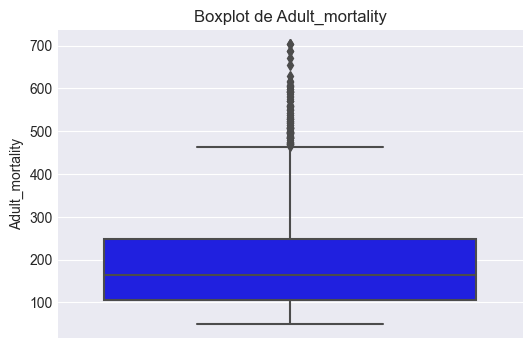

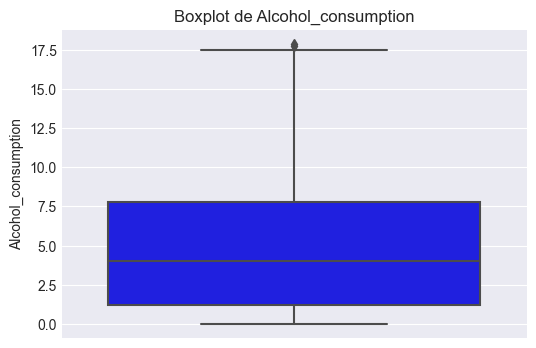

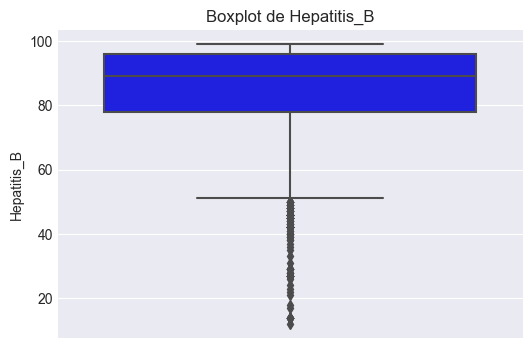

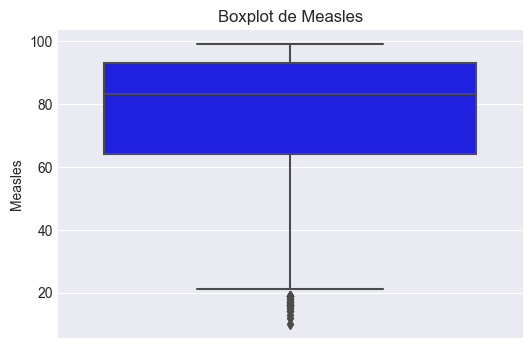

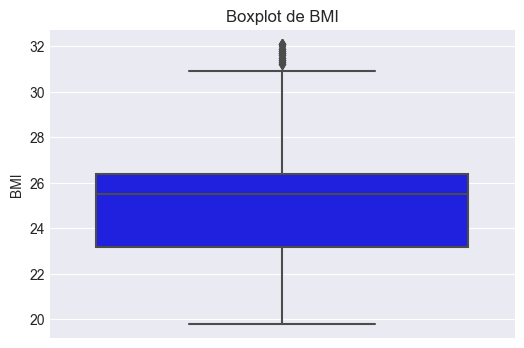

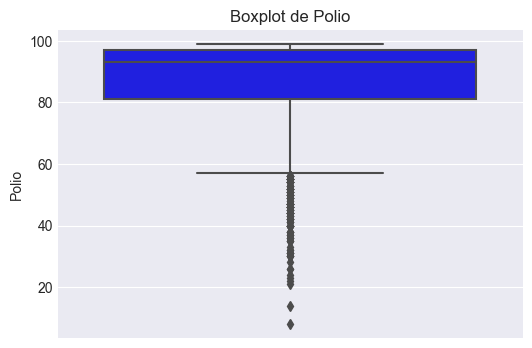

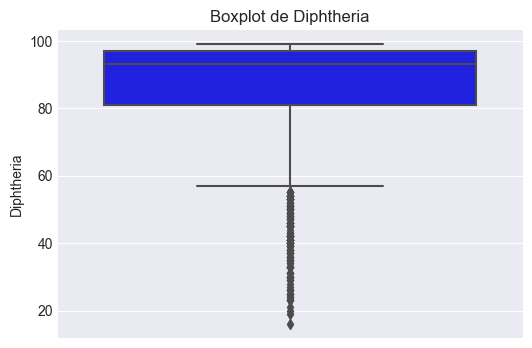

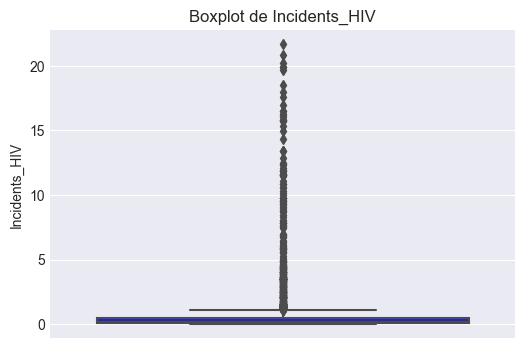

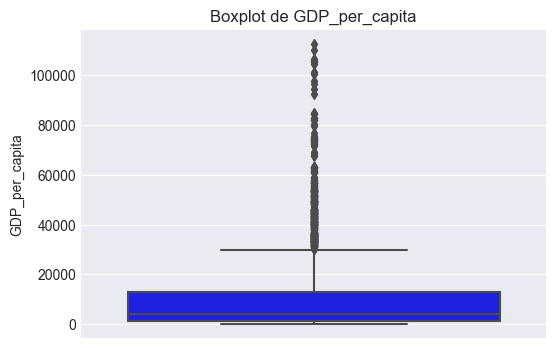

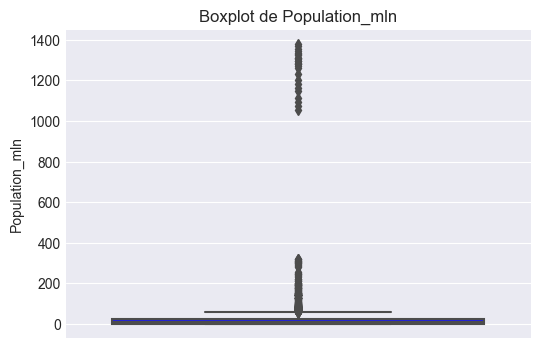

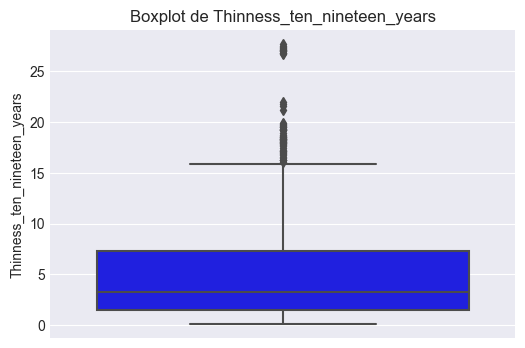

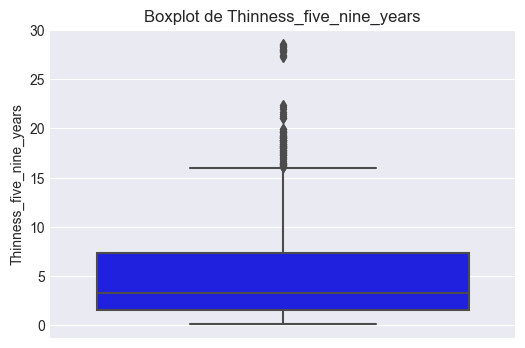

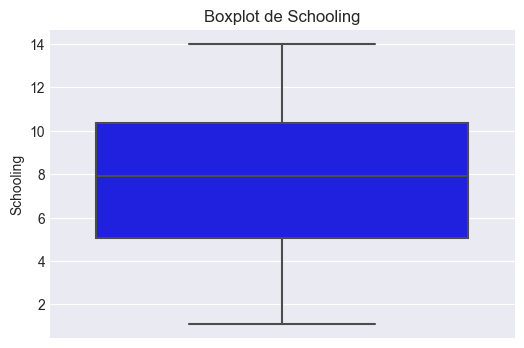

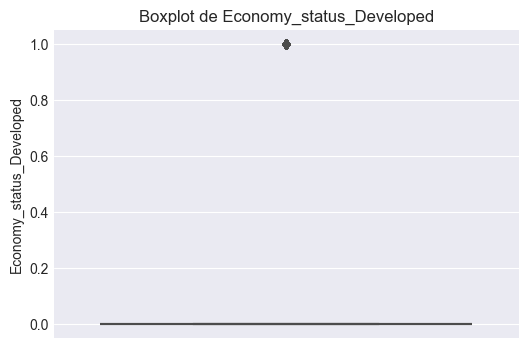

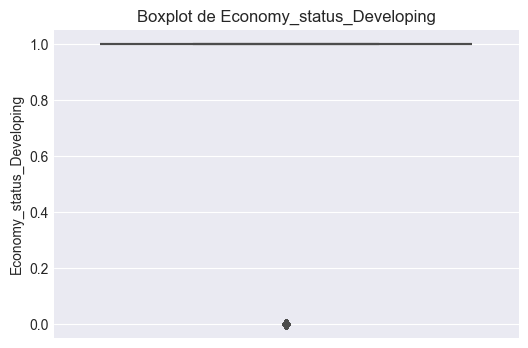

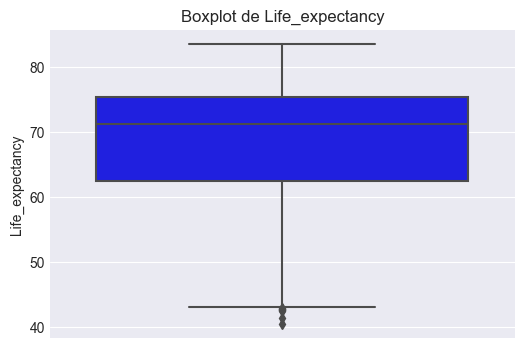

In [18]:
# Affichage des boxplots pour chaque variable numérique
num_cols = list(train.select_dtypes(include=["float64", "int64"]).columns)

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=train, y=col, color="blue")
    plt.title(f"Boxplot de {col}")
    plt.ylabel(col)
    plt.show()

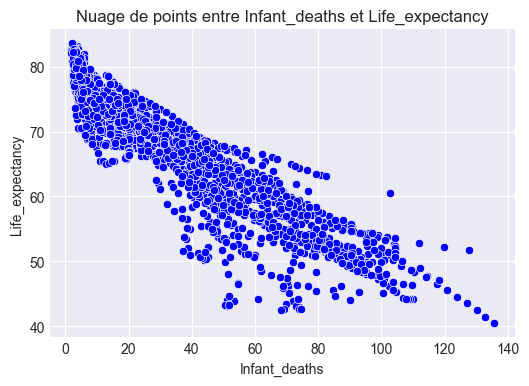

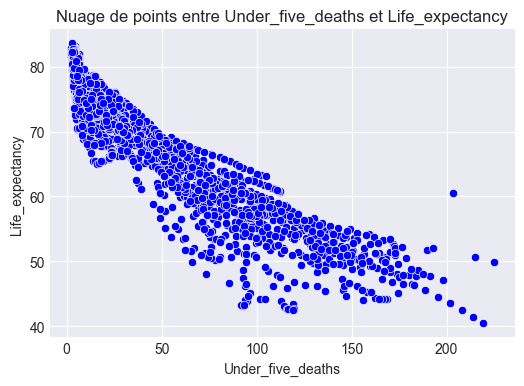

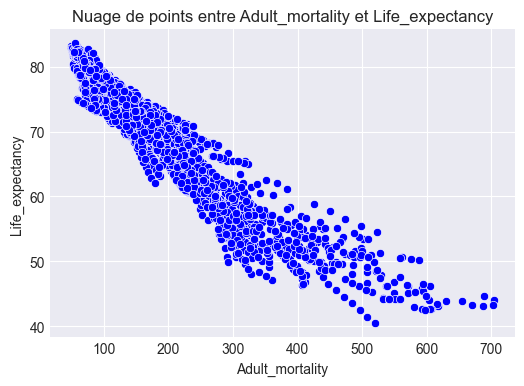

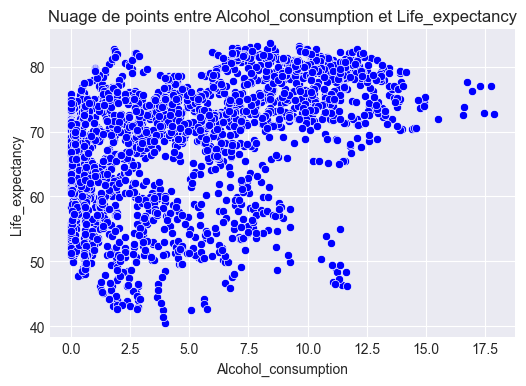

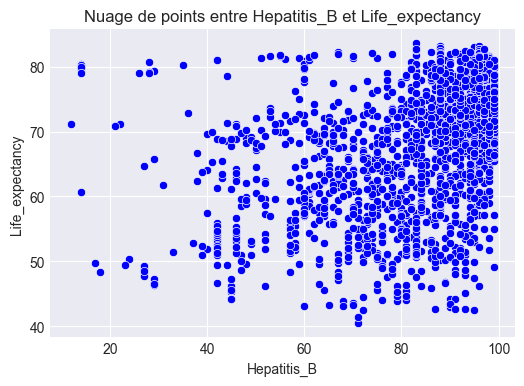

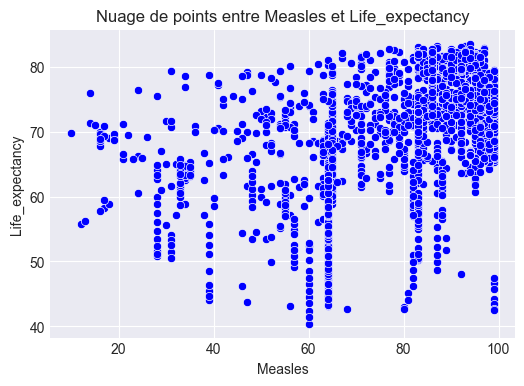

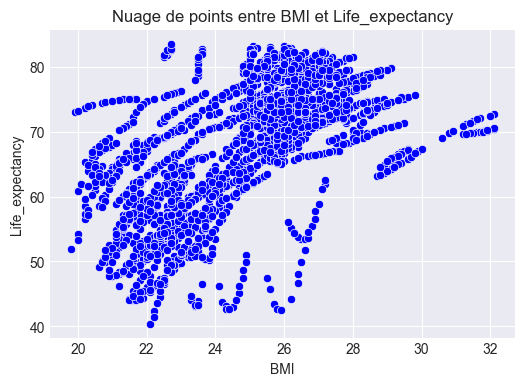

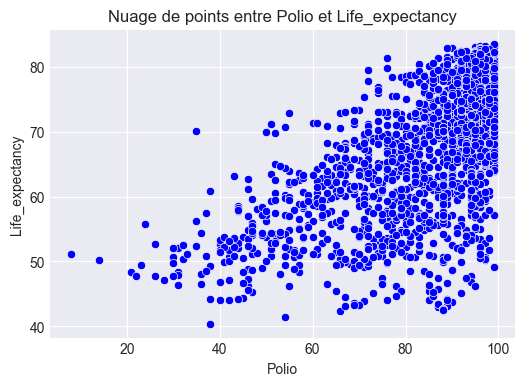

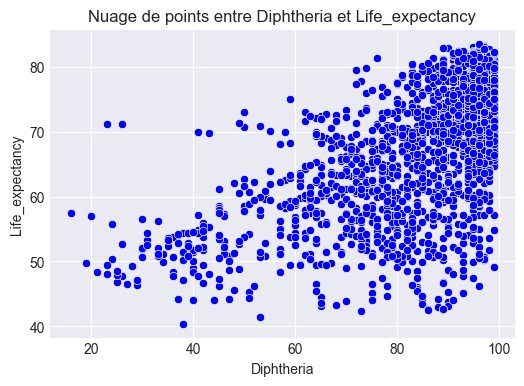

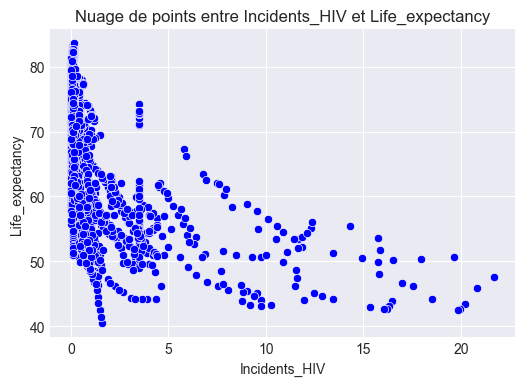

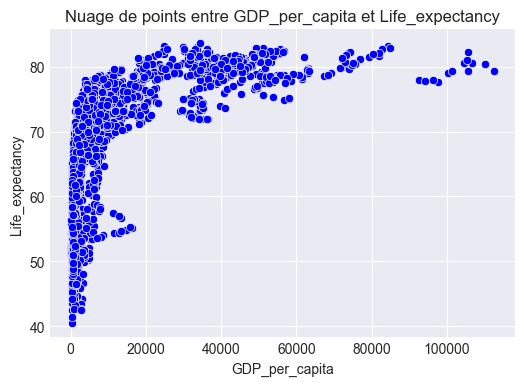

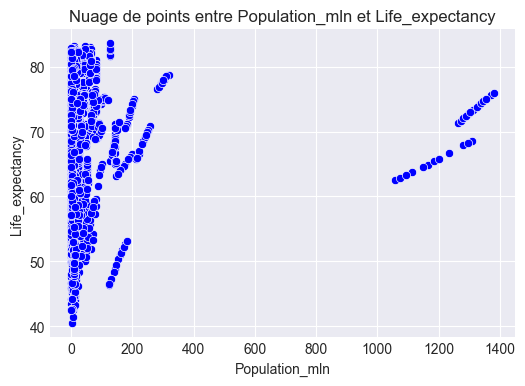

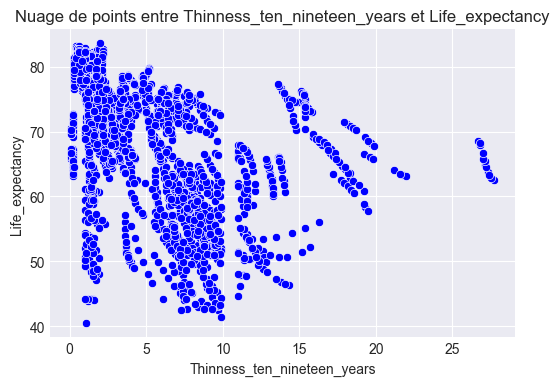

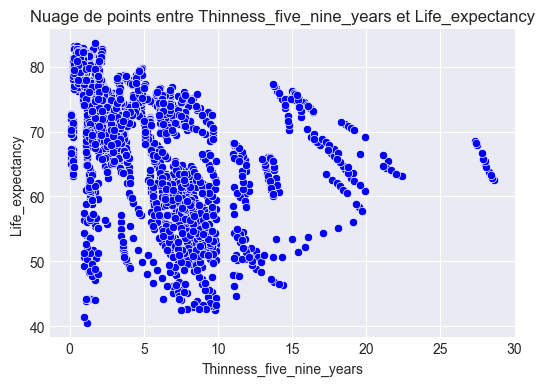

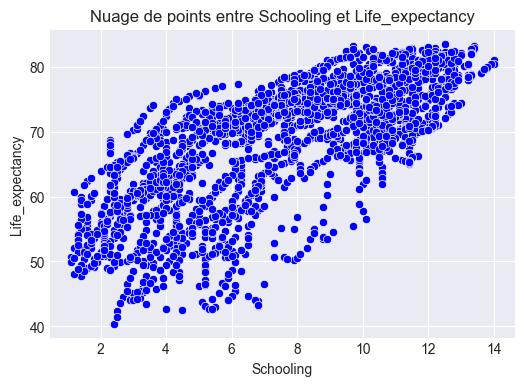

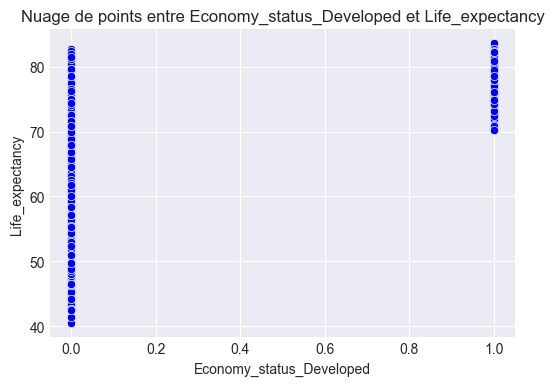

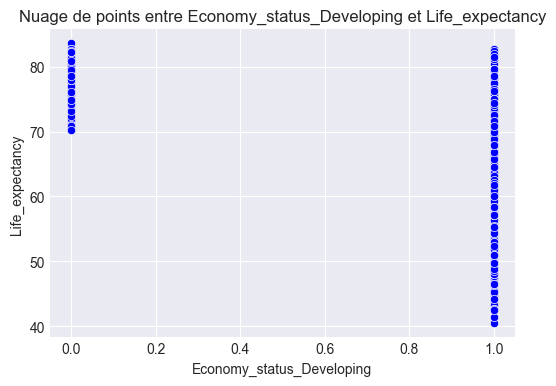

In [19]:
# Affichage des nuages de points entre la variable d'intérêt et toutes les autres variables
target_col = "Life_expectancy"
num_cols = list(train.select_dtypes(include=["float64", "int64"]).columns)
num_cols.remove(target_col)

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=train, x=col, y=target_col, color="blue")
    plt.title(f"Nuage de points entre {col} et {target_col}")
    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.show()

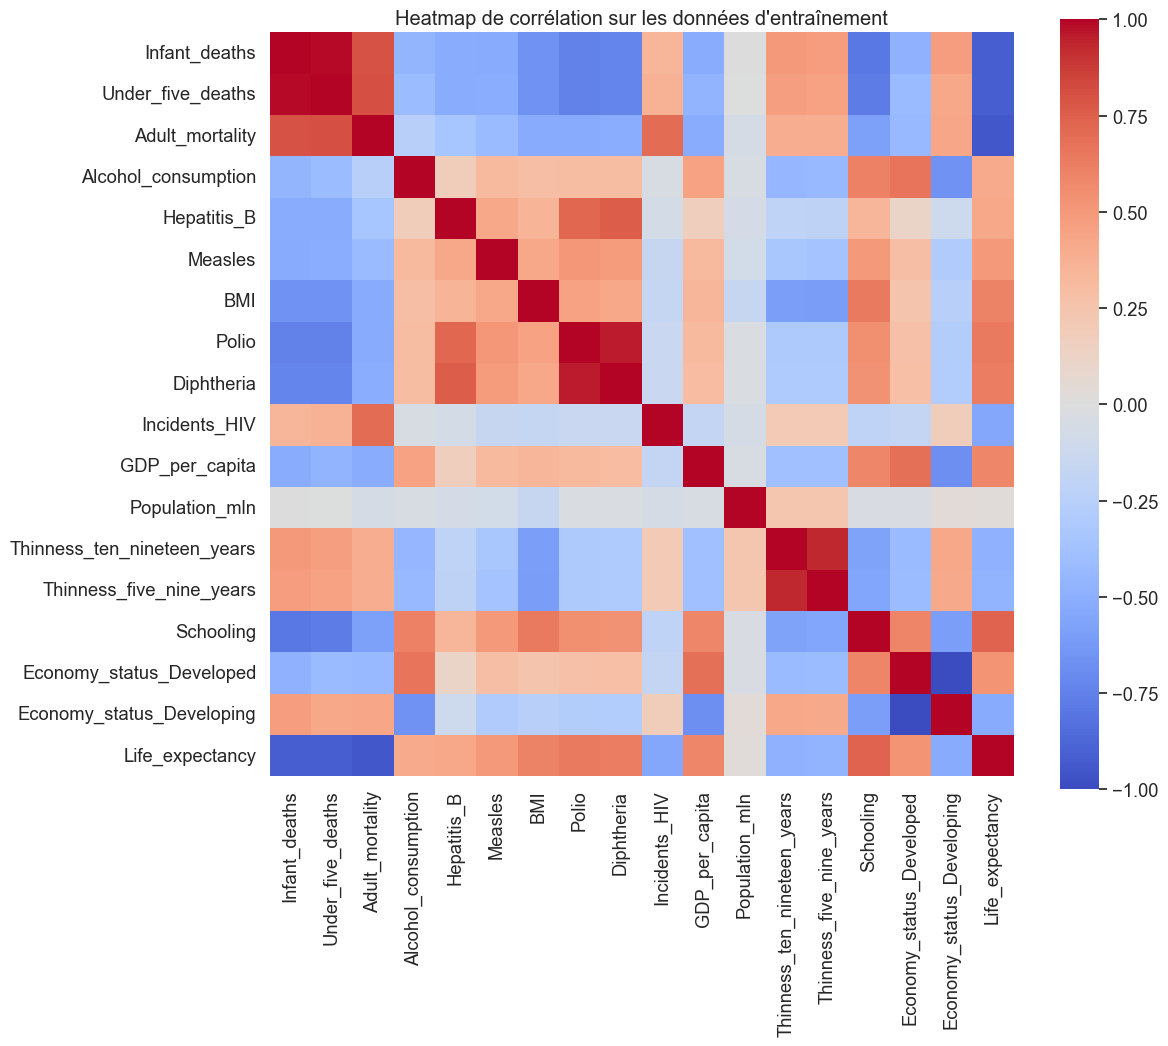

In [20]:
# Calcul de la matrice de corrélation sur les données d'entraînement
corr_matrix_train = train.corr()


sns.set(font_scale=1.2)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_train, cmap="coolwarm", annot_kws={"size": 10}, square=True, fmt=".2f")

# Affichage du graphique
import matplotlib.pyplot as plt

plt.title("Heatmap de corrélation sur les données d'entraînement")
plt.show()

SELECTION DES VARIABLES

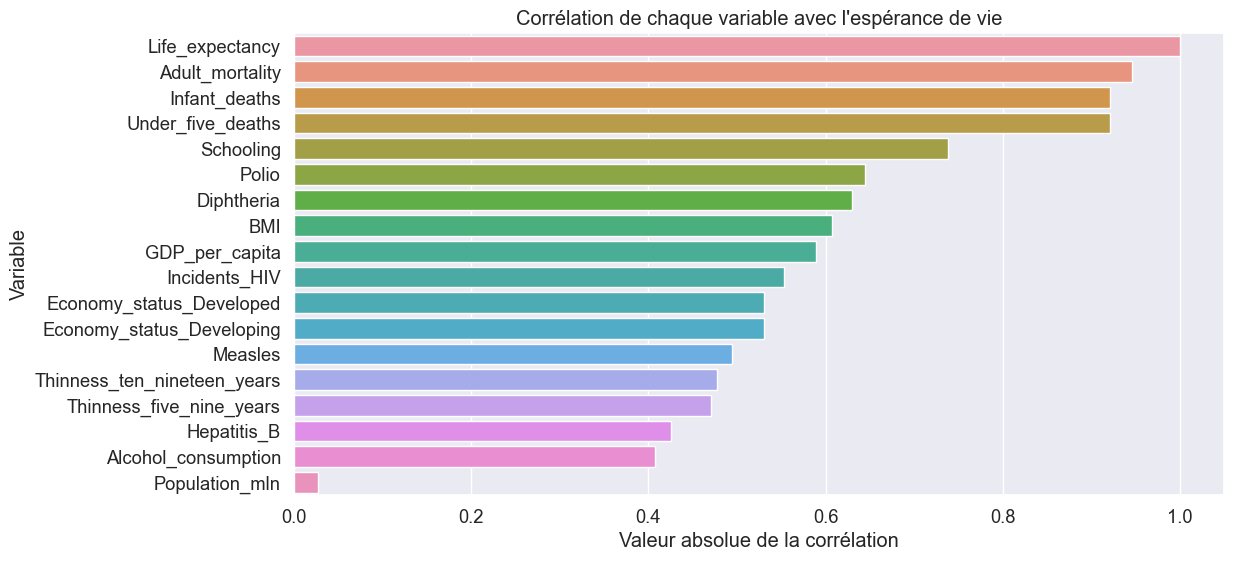

In [21]:
# Calcul de la corrélation entre chaque variable et la variable cible (en valeur absolue)
correlations = abs(train.corr()["Life_expectancy"]).sort_values(ascending=False)

# Représentation graphique des corrélations
plt.figure(figsize=(12, 6))
sns.barplot(x=correlations.values, y=correlations.index)
plt.xlabel("Valeur absolue de la corrélation")
plt.ylabel("Variable")
plt.title("Corrélation de chaque variable avec l'espérance de vie")
plt.show()

Modélisation sur la base train

In [22]:
import statsmodels.api as sm
# Séparation des variables prédictives et de la variable cible
X_train = train.drop("Life_expectancy", axis=1)
y_train = train["Life_expectancy"]


X_test = test.drop("Life_expectancy", axis=1)
y_test = test["Life_expectancy"]

# Fit du modèle linéaire
lr_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()

# Obtention du tableau de résultats
results_table = lr_model.summary2().tables[1]
results_table

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,56.28,0.46,122.58,0.00,55.38,57.18
Infant_deaths,-0.05,0.01,-7.73,0.00,-0.07,-0.04
Under_five_deaths,-0.05,0.00,-11.83,0.00,-0.06,-0.04
Adult_mortality,-0.05,0.00,-69.18,0.00,-0.05,-0.05
Alcohol_consumption,0.06,0.01,5.75,0.00,0.04,0.09
Hepatitis_B,-0.01,0.00,-2.90,0.00,-0.01,-0.00
Measles,0.00,0.00,0.98,0.33,-0.00,0.01
BMI,-0.13,0.02,-5.99,0.00,-0.17,-0.09
Polio,0.00,0.01,0.31,0.76,-0.01,0.02
Diphtheria,0.00,0.01,0.28,0.78,-0.01,0.01


In [23]:
lr_model.summary2().tables[0]

,0,1,2,3
0,Model:,OLS,Adj. R-squared:,0.979
1,Dependent Variable:,Life_expectancy,AIC:,7934.3755
2,Date:,2026-03-28 11:28,BIC:,8031.9001
3,No. Observations:,2291,Log-Likelihood:,-3950.2
4,Df Model:,16,F-statistic:,6787.
5,Df Residuals:,2274,Prob (F-statistic):,0.00
6,R-squared:,0.979,Scale:,1.8552


In [24]:
# Obtention des prédictions et des métriques d'évaluation
y_train_pred = lr_model.predict(sm.add_constant(X_train))
y_test_pred = lr_model.predict(sm.add_constant(X_test))
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

In [25]:
# Construction du tableau de résultats

df_metrics = pd.DataFrame({
    'Métrique': ['R2', 'MSE', 'RMSE'],
    'Train': [r2_train, mse_train, rmse_train],
    'Test': [r2_test, mse_test, rmse_test]
})

print(df_metrics)

  Métrique  Train  Test
0       R2   0.98  0.98
1      MSE   1.84  1.85
2     RMSE   1.36  1.36


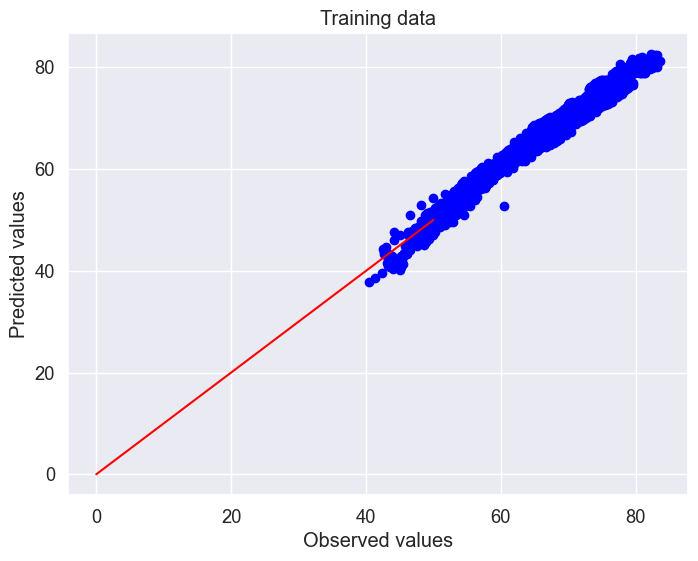

In [26]:
# Tracer les valeurs observées en fonction des valeurs prédites sur les données d'entraînement
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_train_pred, color='blue')
plt.xlabel('Observed values')
plt.ylabel('Predicted values')
plt.title('Training data')
plt.plot(np.arange(0, 55, 5), np.arange(0, 55, 5), color='red')
plt.show()

Vérification des hypothèses du modèles

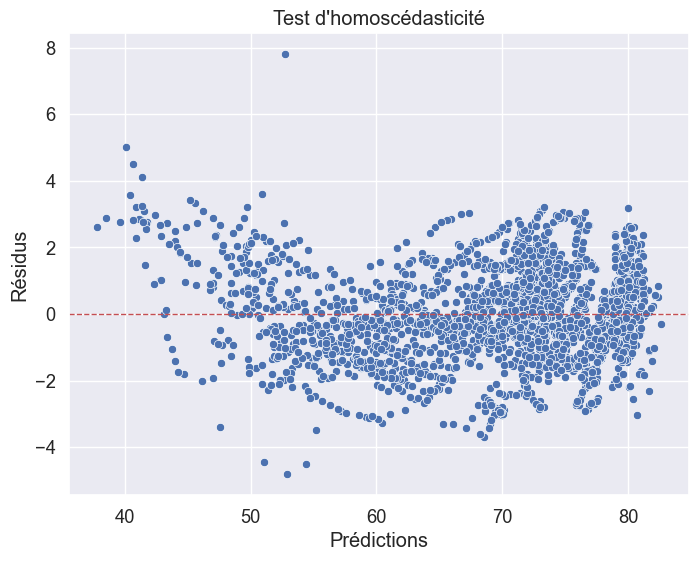

In [27]:
y_train_pred = lr_model.predict(sm.add_constant(X_train))
residuals = y_train - y_train_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_train_pred, y=residuals)  # Correction: utiliser x et y
plt.axhline(y=0, color='r', linestyle='--', linewidth=1)  # Ligne horizontale à 0
plt.title('Test d\'homoscédasticité')
plt.xlabel('Prédictions')
plt.ylabel('Résidus')
plt.show()


In [28]:
# Test de Breusch-Pagan
bp_test = sm.stats.diagnostic.het_breuschpagan(lr_model.resid, lr_model.model.exog)
print("Test de Breusch-Pagan : statistique = %f, p-value = %f" % (bp_test[0], bp_test[1]))

Test de Breusch-Pagan : statistique = 252.152278, p-value = 0.000000


VERIFICATION DE MULTICOLINEARITE

In [29]:

# Test de multicollinéarité
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif["features"] = X_train.columns
print(vif)

    VIF Factor                     features
0        46.36                Infant_deaths
1        47.00            Under_five_deaths
2         8.07              Adult_mortality
3         2.41          Alcohol_consumption
4         2.59                  Hepatitis_B
5         1.59                      Measles
6         2.80                          BMI
7        12.42                        Polio
8        13.50                   Diphtheria
9         2.93                Incidents_HIV
10        2.42               GDP_per_capita
11        1.14               Population_mln
12        8.64  Thinness_ten_nineteen_years
13        8.64     Thinness_five_nine_years
14        4.46                    Schooling
15      120.78     Economy_status_Developed
16      473.34    Economy_status_Developing


Tester d'autres modèles

In [30]:
train.columns

Index(['Infant_deaths', 'Under_five_deaths', 'Adult_mortality',
       'Alcohol_consumption', 'Hepatitis_B', 'Measles', 'BMI', 'Polio',
       'Diphtheria', 'Incidents_HIV', 'GDP_per_capita', 'Population_mln',
       'Thinness_ten_nineteen_years', 'Thinness_five_nine_years', 'Schooling',
       'Economy_status_Developed', 'Economy_status_Developing',
       'Life_expectancy'],
      dtype='str')

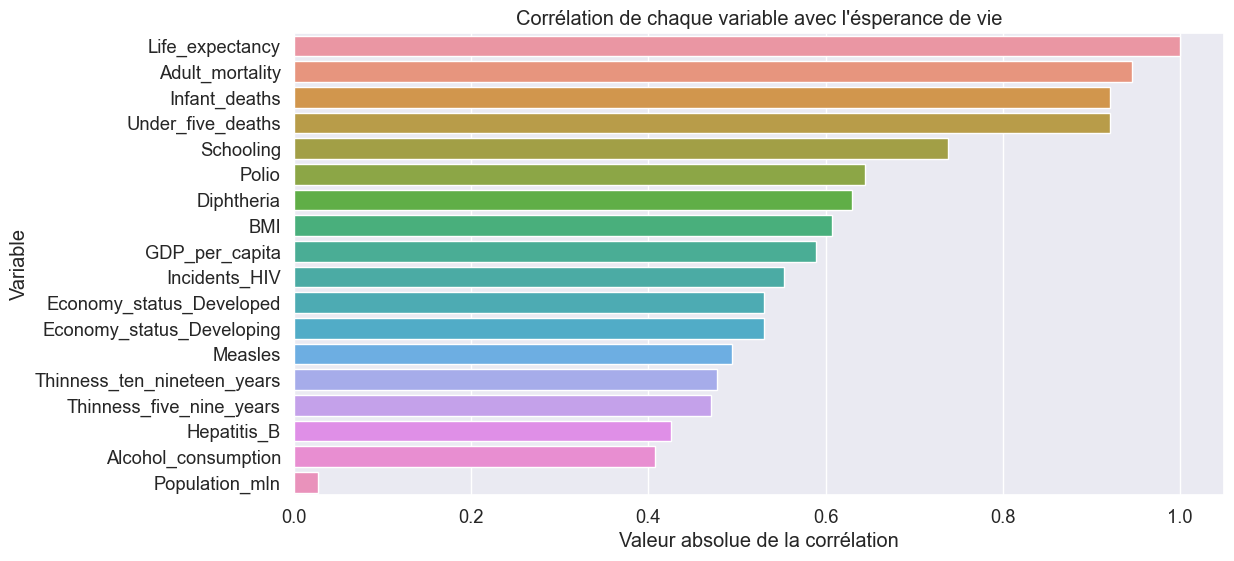

In [31]:
# Représentation graphique des corrélations
plt.figure(figsize=(12, 6))
sns.barplot(x=correlations.values, y=correlations.index)
plt.xlabel("Valeur absolue de la corrélation")
plt.ylabel("Variable")
plt.title("Corrélation de chaque variable avec l'ésperance de vie")
plt.show()

Selection des variables dont le VIF est inférieur ou égale à 10

In [32]:
new_selection=['Adult_mortality',
       'Alcohol_consumption', 
      'Incidents_HIV', 'GDP_per_capita', 'Population_mln']
train_selectedb = train[new_selection]
train_selectedb["Life_expectancy"] = train["Life_expectancy"]
train_selectedb

,Adult_mortality,Alcohol_consumption,Incidents_HIV,GDP_per_capita,Population_mln,Life_expectancy
Country,,,,,,
Sri Lanka,111.28,2.45,0.01,3694,20.78,76.10
Czechia,114.30,13.42,0.08,14070,10.20,75.70
"Venezuela, RB",143.08,6.60,0.40,16056,30.04,72.80
Albania,80.94,4.88,0.03,3577,2.91,76.60
Namibia,495.73,2.29,9.74,3298,1.88,50.60
...,...,...,...,...,...,...
"Micronesia, Fed. Sts.",184.96,2.23,0.17,2895,0.11,64.60
Bhutan,283.93,1.42,0.23,1176,0.60,61.80
Cabo Verde,135.01,4.25,0.27,3079,0.48,70.80


In [33]:
# Séparation des variables prédictives et de la variable cible
X_train = train_selectedb.drop("Life_expectancy", axis=1)
y_train = train_selectedb["Life_expectancy"]

# Fit du modèle linéaire
lr_modelb = sm.OLS(y_train, sm.add_constant(X_train)).fit()

# Obtention du tableau de résultats
results_table = lr_modelb.summary2().tables[1]
results_table

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
const,82.31,0.17,495.10,0.00,81.98,82.63
Adult_mortality,-0.08,0.00,-116.33,0.00,-0.08,-0.08
Alcohol_consumption,0.34,0.01,25.09,0.00,0.32,0.37
Incidents_HIV,0.64,0.03,21.57,0.00,0.59,0.70
GDP_per_capita,0.00,0.00,4.55,0.00,0.00,0.00
Population_mln,-0.00,0.00,-2.34,0.02,-0.00,-0.00


In [34]:
lr_modelb.summary2().tables[0]

,0,1,2,3
0,Model:,OLS,Adj. R-squared:,0.940
1,Dependent Variable:,Life_expectancy,AIC:,10349.4187
2,Date:,2026-03-28 11:28,BIC:,10383.8392
3,No. Observations:,2291,Log-Likelihood:,-5168.7
4,Df Model:,5,F-statistic:,7233.
5,Df Residuals:,2285,Prob (F-statistic):,0.00
6,R-squared:,0.941,Scale:,5.3491


In [35]:
# Reconstruire X_train et X_test pour le modèle B
X_train_b = train[new_selection]
y_train_b  = train["Life_expectancy"]

X_test_b   = test[new_selection]
y_test_b   = test["Life_expectancy"]

# Prédictions
y_train_pred_b = lr_modelb.predict(sm.add_constant(X_train_b))
y_test_pred_b  = lr_modelb.predict(sm.add_constant(X_test_b))

# Tableau des métriques
df_metrics_b = pd.DataFrame({
    'Métrique': ['R2', 'MSE', 'RMSE'],
    'Train': [r2_score(y_train_b, y_train_pred_b),
              mean_squared_error(y_train_b, y_train_pred_b),
              np.sqrt(mean_squared_error(y_train_b, y_train_pred_b))],
    'Test':  [r2_score(y_test_b, y_test_pred_b),
              mean_squared_error(y_test_b, y_test_pred_b),
              np.sqrt(mean_squared_error(y_test_b, y_test_pred_b))]
})
print(df_metrics_b)

  Métrique  Train  Test
0       R2   0.94  0.93
1      MSE   5.34  5.80
2     RMSE   2.31  2.41


In [36]:
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif["features"] = X_train.columns
print(vif)

   VIF Factor             features
0        2.61      Adult_mortality
1        2.73  Alcohol_consumption
2        1.79        Incidents_HIV
3        1.92       GDP_per_capita
4        1.06       Population_mln


VERIFICATION DE LA NORMALITE

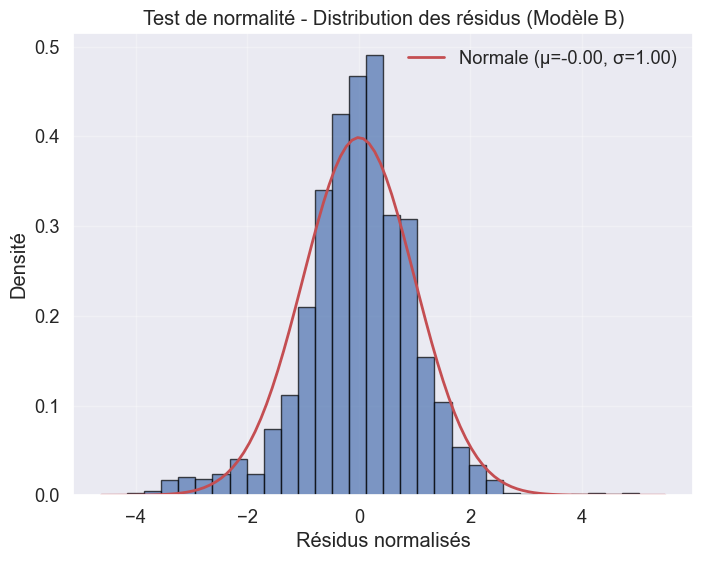

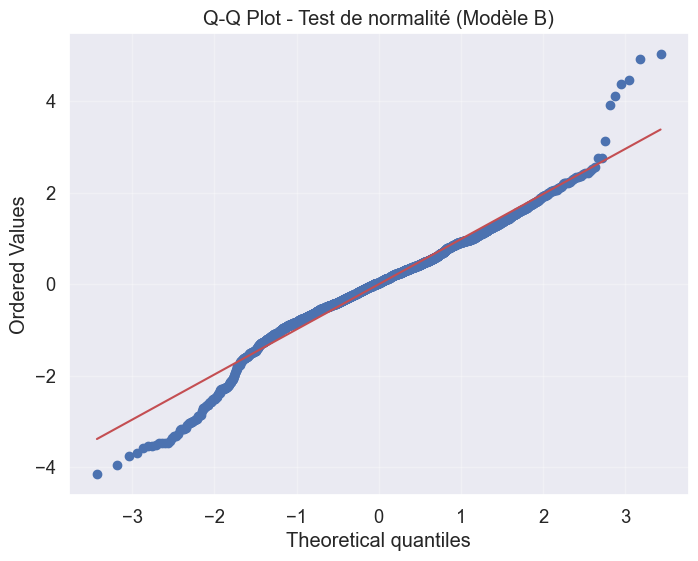

In [37]:
import scipy.stats as stats

# Résidus du modèle B
residuals_b = y_train_b - lr_modelb.predict(sm.add_constant(X_train_b))

# Test de normalité
resid_norm = lr_modelb.get_influence().resid_studentized_internal

plt.figure(figsize=(8, 6))
n, bins, patches = plt.hist(resid_norm, bins=30, edgecolor='black', 
                            alpha=0.7, density=True)

mu, std = stats.norm.fit(resid_norm)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r-', linewidth=2, label=f'Normale (μ={mu:.2f}, σ={std:.2f})')
plt.title('Test de normalité - Distribution des résidus (Modèle B)')
plt.xlabel('Résidus normalisés')
plt.ylabel('Densité')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Q-Q plot
plt.figure(figsize=(8, 6))
stats.probplot(resid_norm, dist="norm", plot=plt)
plt.title('Q-Q Plot - Test de normalité (Modèle B)')
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
shapiro_test  = stats.shapiro(residuals_b)
anderson_test = stats.anderson(residuals_b, dist='norm')
ks_test       = stats.kstest(residuals_b, 'norm')

df_normality = pd.DataFrame({
    'Test de normalité': ['Shapiro-Wilk', 'Anderson-Darling', 'Kolmogorov-Smirnov'],
    'Statistique': [shapiro_test.statistic, anderson_test.statistic, ks_test.statistic],
    'p-value': [shapiro_test.pvalue, 'N/A', ks_test.pvalue]
})
print(df_normality)

    Test de normalité  Statistique p-value
0        Shapiro-Wilk         0.97    0.00
1    Anderson-Darling        12.84     N/A
2  Kolmogorov-Smirnov         0.17    0.00


Verification d'autocorelation 

In [39]:
from statsmodels.stats.stattools import durbin_watson
dw_test = durbin_watson(lr_modelb.resid)
print("Test de Durbin-Watson : statistique = %f" % dw_test)

Test de Durbin-Watson : statistique = 1.950494


Moyennes des termes de erreurs 

In [40]:
residuals.mean()

np.float64(-7.972655466606847e-13)